# Student Depression -Machine Learning Project 

## Business Understanding

Our goal is to extract meaningful and concrete tips and advice for students to help combat depression: finding breakpoints for sleep amounts, academic pressure and studying the possible correlative effects of family mental illness history. 

A decision tree-based approach is best suited for this as each nodes' binary decision has insight on how to avoid getting depressed.

## Data Understanding

The dataset we're working with contains information about students across various Indian cities, capturing demographic information, academic factors, lifestyle habits, and mental health indicators. The target variable, Depression, is a binary classification where 1 indicates the presence of depression and 0 indicates its absence.



In [290]:
import pandas as pd

df = pd.read_csv('datasets/student_depression_dataset.csv')

df.tail(5)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1
27900,140699,Male,27.0,Patna,Student,4.0,0.0,9.24,1.0,0.0,'Less than 5 hours',Healthy,BCA,Yes,2.0,3.0,Yes,1


From the data types, we can see that Academic Pressure is type float (1.0-5.0) and Financial Stress is also a range from 1.0-5.0, but it is typed as string. Later we need to adjust that for better model performance.

In [291]:
df.dtypes

id                                         int64
Gender                                       str
Age                                      float64
City                                         str
Profession                                   str
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                               str
Dietary Habits                               str
Degree                                       str
Have you ever had suicidal thoughts ?        str
Work/Study Hours                         float64
Financial Stress                             str
Family History of Mental Illness             str
Depression                                 int64
dtype: object

In [292]:
print(f'Amount of rows in the dataset: {df.shape[0]}')


Amount of rows in the dataset: 27901


In [293]:
vc = df['Depression'].value_counts(normalize=True)
incidence = vc.get(1, 0) * 100
print(f"Incidence of depression within dataset: {incidence:.2f}%")
df['Depression'].value_counts(normalize=True)

Incidence of depression within dataset: 58.55%


Depression
1    0.585499
0    0.414501
Name: proportion, dtype: float64

The amount of depressed students in the data seems to be higher than publicly available research would imply even though the dataset is large. Either the survey participant group is biased, or the dataset is not based on real data.

Next we check dataset for missing values:

In [294]:
missing_values = df.isnull().sum()
print(missing_values)

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


There were no missing values detected with isnull(), but we found some entries marked as '?' in the 'Financial Stress' column. While this amount does not break the model, they are still important to note.

In [295]:
question_mark_counts = (df == '?').sum()
print(question_mark_counts)

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64


## Data Preparation

We are preparing the dataset for modeling. This includes encoding categorical variables, separating features and target and splitting the data into for training and testing.

As earlier mentioned Financial Stress column was typed as string, next we cast it to float for better model performance.

errors='coerse' allows us to convert non-castable items to NaN, important because of the earlier '?' findings.

In [296]:
df['Financial Stress'] = pd.to_numeric(df['Financial Stress'], errors='coerce')

In [297]:
df.dtypes

id                                         int64
Gender                                       str
Age                                      float64
City                                         str
Profession                                   str
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                               str
Dietary Habits                               str
Degree                                       str
Have you ever had suicidal thoughts ?        str
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness             str
Depression                                 int64
dtype: object

We see that earlier '?' rows are now detectable with isnull().

In [298]:
missing_financial_stress_values = df['Financial Stress'].isnull().sum()
print(missing_financial_stress_values)

3


Next we fill these with a median value.

In [299]:
df['Financial Stress'] = df['Financial Stress'].fillna(df['Financial Stress'].median())

mfsv = df['Financial Stress'].isnull().sum()
print(mfsv)

0


In [300]:
from sklearn.model_selection import train_test_split

df = pd.get_dummies(df)

X = df.drop(['Depression'], axis = 1) # input features
y = df['Depression'].astype('category') # target features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=20) # extract test set


The dataset has been split into training and testing sets:

In [301]:
print(f"Training set (X_train) shape: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set (X_test) shape: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Training labels (y_train) shape: {y_train.shape[0]} samples")
print(f"Testing labels (y_test) shape: {y_test.shape[0]} samples")

Training set (X_train) shape: 20925 samples, 118 features
Testing set (X_test) shape: 6976 samples, 118 features
Training labels (y_train) shape: 20925 samples
Testing labels (y_test) shape: 6976 samples


The categorical columns have been one-hot encoded, so the model can properly interpret and use them.

In [302]:
X

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Gender_Female,...,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD,Have you ever had suicidal thoughts ?_No,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_No,Family History of Mental Illness_Yes
0,2,33.0,5.0,0.0,8.97,2.0,0.0,3.0,1.0,False,...,False,False,False,False,False,False,False,True,True,False
1,8,24.0,2.0,0.0,5.90,5.0,0.0,3.0,2.0,True,...,False,False,False,False,False,False,True,False,False,True
2,26,31.0,3.0,0.0,7.03,5.0,0.0,9.0,1.0,False,...,False,False,False,False,False,False,True,False,False,True
3,30,28.0,3.0,0.0,5.59,2.0,0.0,4.0,5.0,True,...,False,False,False,False,False,False,False,True,False,True
4,32,25.0,4.0,0.0,8.13,3.0,0.0,1.0,1.0,True,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,27.0,5.0,0.0,5.75,5.0,0.0,7.0,1.0,True,...,False,False,False,False,False,False,False,True,False,True
27897,140686,27.0,2.0,0.0,9.40,3.0,0.0,0.0,3.0,False,...,False,False,False,True,False,False,True,False,False,True
27898,140689,31.0,3.0,0.0,6.61,4.0,0.0,12.0,2.0,False,...,True,False,False,False,False,False,True,False,True,False
27899,140690,18.0,5.0,0.0,6.88,2.0,0.0,10.0,5.0,True,...,False,False,False,False,False,False,False,True,True,False


## Modeling

In [303]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier(max_depth=3, random_state=20)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",20
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

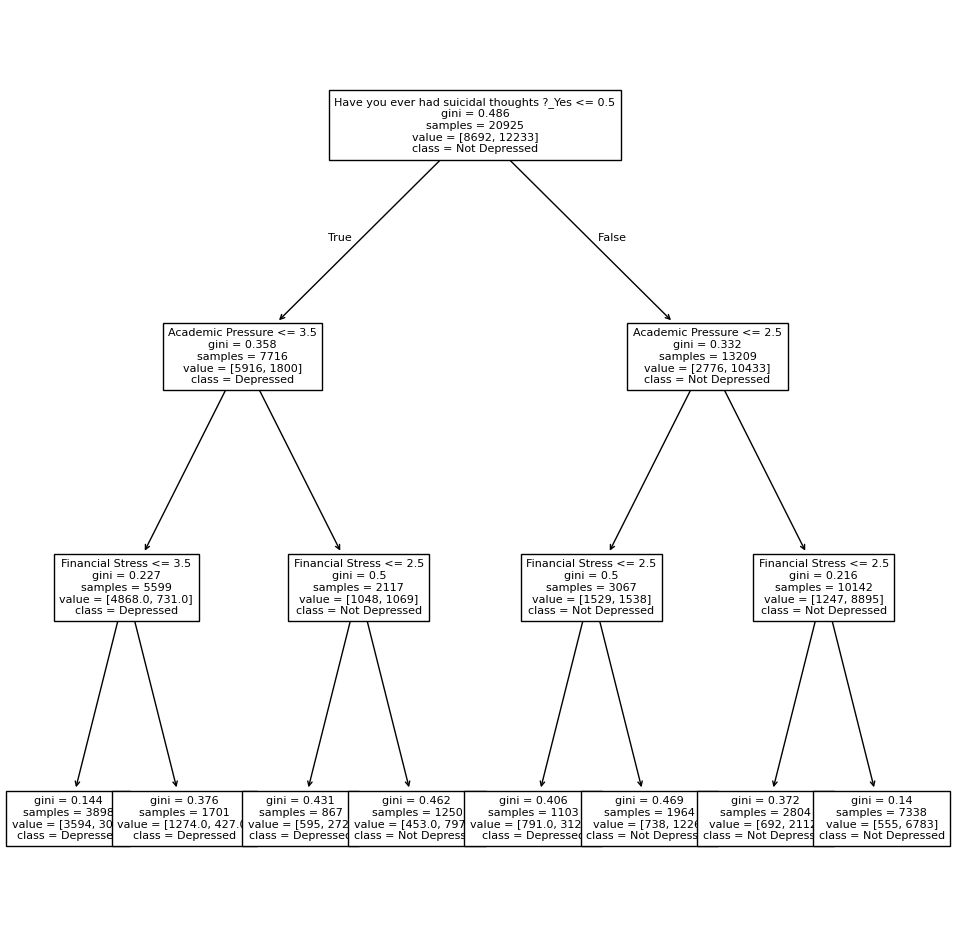

In [304]:
fig = plt.figure(figsize = (12, 12))
plot_tree(model, feature_names = X.keys(), class_names = ['Depressed', 'Not Depressed'], fontsize=8)
plt.show()

The decision tree shows which factors appear most strongly associated with depression risk among students. The model suggests that suicidal thoughts, academic pressure, and financial stress are among the most important variables separating depressed and non-depressed students. Variables such as sleep duration or family history of mental illness did not appear among the top splits in the decision tree, suggesting that these variables have less influence to students compared to academic pressure and financial stress.

## Evaluation and Validation

We used 10-fold cross-validation to evaluate the performance of the model.

In [305]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Perform 10-fold cross-validation on the training data
cv_scores = cross_val_score(model, X_train, y_train, cv=10)

print(f"Cross-validation accuracies:{cv_scores.round(3)}")
print(f"Average accuracy: {cv_scores.mean().round(3)}")

# Train the final model using the full training dataset
model.fit(X_train, y_train)

# Evaluate the model using the test dataset
y_pred = model.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))

Cross-validation accuracies:[0.821 0.82  0.811 0.829 0.817 0.821 0.818 0.809 0.825 0.828]
Average accuracy: 0.82
Test accuracy: 0.825


The cross-validation results show accuracies from 0.80 to 0.828 across the different folds. The average accuracy is 0.82, which indicates that the model performs consistently across different training splits.

After the validation step, we trained the final decision tree model using the full training dataset and evaluated it on the separate test dataset. The model achieved a test accuracy of approximately 0.81, which is close to the cross-validation result.

We used a confusion matrix to evaluate the model’s prediction errors.

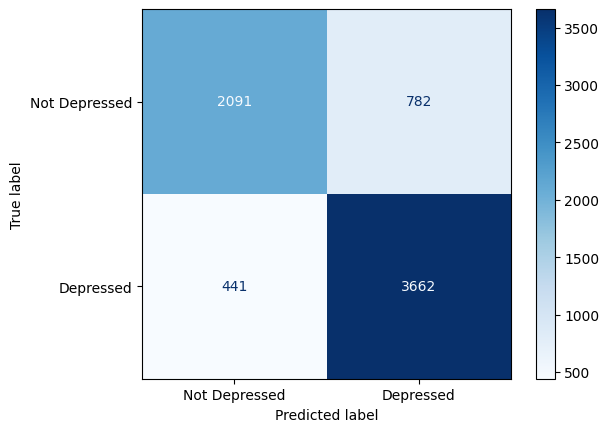

In [306]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=['Not Depressed', 'Depressed'])
cmd.plot(cmap='Blues')


The confusion matrix shows that the model correctly identified 3662 students with depression and 2091 students without depression. However, 441 students with depression were not detected by the model, and 782 students were incorrectly predicted as depressed. The results indicate that while the model performs reasonably well overall, some cases of depression remained undetected.

To further evaluate the performance of the model we calculated accuracy, precision and recall from the test dataset.

In [307]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy_test = accuracy_score(y_test, y_pred)

# Precision
precision_test = precision_score(y_test, y_pred, pos_label=1)

# Recall
recall_test = recall_score(y_test, y_pred, pos_label=1)

print(f"Accuracy: {accuracy_test:.3f}")
print(f"Precision: {precision_test:.3f}")
print(f"Recall: {recall_test:.3f}")

Accuracy: 0.825
Precision: 0.824
Recall: 0.893


The model achieved an accuracy of 0.825, meaning that approximately 83% of the predictions were correct. The precision of 0.824 indicates that when the model predicts depression, it is correct in most cases. The recall of 0.893 shows that the model successfully identifies almost 90% of the students who actually have depression, while some cases remain undetected.

Considering these, the model's high recall is beneficial because it minimizes false negatives, meaning most students who are actually experiencing depression are correctly identified. On the negative side, the model's lower precision means it sometimes flags students who are not experiencing depression.

## Deployment

The model could be used as part of a digital tool designed to support student wellbeing. For example, the model could be used in an application where students answer questions related to factors such as sleep duration, academic pressure, study satisfaction and financial stress, and the model could estimate the likelihood of depression and provide recommendations.